Top performers (sig & LFC > 0.5): 216
Bottom performers (sig & LFC < -0.5): 63


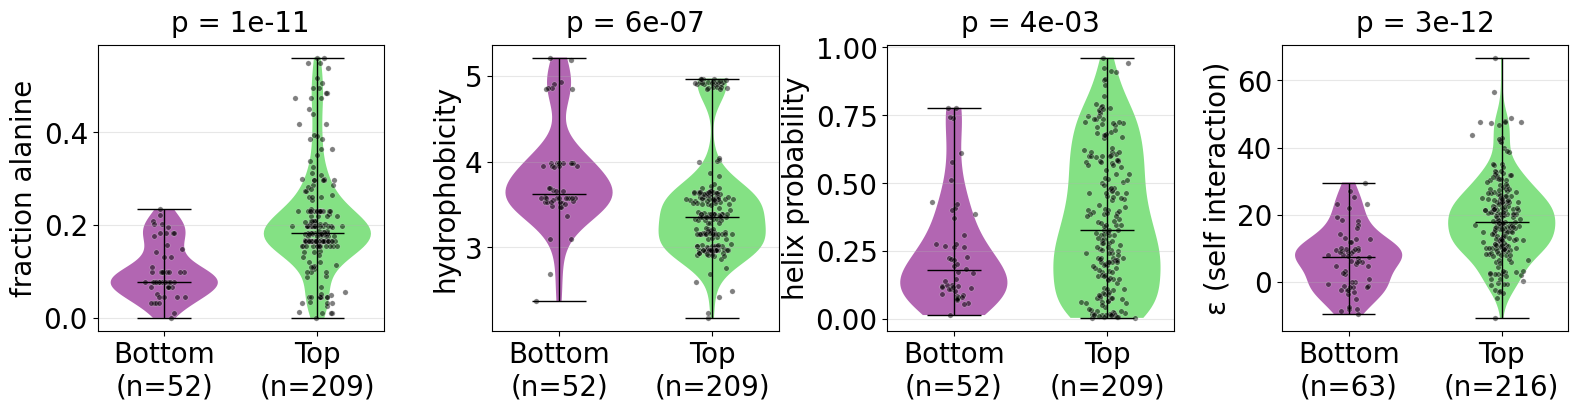


Statistics:
                      feature       pvalue         padj    direction
finches_calvados_epsilon_self 2.976270e-12 1.190508e-11 Top > Bottom
           nardini_Frac A_raw 1.394519e-11 2.789038e-11 Top > Bottom
   nardini_Hydrophobicity_raw 6.451096e-07 8.601462e-07 Bottom > Top
       sparrow_avg_helix_prob 4.145697e-03 4.145697e-03 Top > Bottom


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt

# Load data
df1 = pd.read_csv('/../../Data/Figure_5/sequencing_data_all.csv')

# Identify columns for each replicate
lfc_cols = sorted([c for c in df1.columns if c.startswith('log2FoldChange_rep')
                   and c[-1] in ['1', '2', '3']])
se_cols  = sorted([c for c in df1.columns if c.startswith('lfcSE_rep')
                   and c[-1] in ['1', '2', '3']])

# Calculate weighted statistics
lfc_data = df1[lfc_cols].values
se_data  = df1[se_cols].values
weights  = 1 / (se_data ** 2)

weighted_lfc = np.nansum(weights * lfc_data, axis=1) / np.nansum(weights, axis=1)
pooled_se    = 1 / np.sqrt(np.nansum(weights, axis=1))
z_scores     = weighted_lfc / pooled_se
pvalues      = 2 * stats.norm.sf(np.abs(z_scores))

df1['weighted_log2FC'] = weighted_lfc
df1['pooled_SE']       = pooled_se
df1['pvalue']          = pvalues

# Multiple testing correction
valid_mask = np.isfinite(df1['pvalue'])
_, padj_values, _, _ = multipletests(df1.loc[valid_mask, 'pvalue'], method='fdr_bh')
df1['padj'] = np.nan
df1.loc[valid_mask, 'padj'] = padj_values

# Replace invalid values with NaN
if 'sparrow_scaling_exponent' in df1.columns:
    df1.loc[df1['sparrow_scaling_exponent'] <= 0, 'sparrow_scaling_exponent'] = np.nan
if 'sparrow_asphericity' in df1.columns:
    df1.loc[df1['sparrow_asphericity'] < 0, 'sparrow_asphericity'] = np.nan

# Define top and bottom performers
sig_mask        = df1['padj'] < 0.05
top_performers  = df1[sig_mask & (df1['weighted_log2FC'] > 0.5)]
bottom_performers = df1[sig_mask & (df1['weighted_log2FC'] < -0.5)]

print(f"Top performers (sig & LFC > 0.5): {len(top_performers)}")
print(f"Bottom performers (sig & LFC < -0.5): {len(bottom_performers)}")

# Selected features
selected_features = [
    'nardini_Frac A_raw',
    'nardini_Hydrophobicity_raw',
    'sparrow_avg_helix_prob',
    'finches_calvados_epsilon_self',
]
chem_cols = [f for f in selected_features if f in df1.columns]
missing   = [f for f in selected_features if f not in df1.columns]
if missing:
    print(f"Warning: features not found in dataframe: {missing}")

label_map = {
    'nardini_Frac A_raw':            'fraction alanine',
    'nardini_Hydrophobicity_raw':    'hydrophobicity',
    'sparrow_avg_helix_prob':        'helix probability',
    'finches_calvados_epsilon_self': 'ε (self interaction)',
}

# ── Plot ──────────────────────────────────────────────────────────────────────
n_features = len(chem_cols)
panel_size = 4
fig, axes = plt.subplots(1, n_features, figsize=(n_features * panel_size, panel_size))
if n_features == 1:
    axes = [axes]

stat_results = []

for i, feature in enumerate(chem_cols):
    ax = axes[i]

    top_data    = top_performers[feature].dropna().values
    bottom_data = bottom_performers[feature].dropna().values

    try:
        parts = ax.violinplot([bottom_data, top_data], positions=[0, 1],
                              showmeans=False, showmedians=True, widths=0.7)
        parts['bodies'][0].set_facecolor('purple');   parts['bodies'][0].set_alpha(0.6)
        parts['bodies'][1].set_facecolor('limegreen'); parts['bodies'][1].set_alpha(0.6)
        for partname in ['cbars', 'cmins', 'cmaxes', 'cmedians']:
            parts[partname].set_edgecolor('black')
            parts[partname].set_linewidth(1)

        jitter_bottom = np.random.normal(0, 0.06, len(bottom_data))
        jitter_top    = np.random.normal(1, 0.06, len(top_data))
        ax.scatter(jitter_bottom, bottom_data, alpha=0.5, s=15, c='black',
                   edgecolors='white', linewidths=0.3)
        ax.scatter(jitter_top, top_data, alpha=0.5, s=15, c='black',
                   edgecolors='white', linewidths=0.3)

        stat, pval = stats.mannwhitneyu(top_data, bottom_data, alternative='two-sided')
        stat_results.append({
            'feature':       feature,
            'pvalue':        pval,
            'top_median':    np.median(top_data),
            'bottom_median': np.median(bottom_data),
            'top_n':         len(top_data),
            'bottom_n':      len(bottom_data),
        })

        # P-value label
        p_text = f'p = {pval:.0e}'
        y_max   = max(np.max(top_data), np.max(bottom_data))
        y_min   = min(np.min(top_data), np.min(bottom_data))
        y_range = y_max - y_min if (y_max - y_min) != 0 else 1
        ax.text(0.5, y_max + 0.10 * y_range, p_text,
                ha='center', fontsize=20)

    except Exception as e:
        ax.boxplot([bottom_data, top_data], positions=[0, 1], patch_artist=True, widths=0.5)
        print(f"Warning: Plot failed for {feature}: {e}")

    ax.set_xticks([0, 1])
    ax.set_xticklabels([f'Bottom\n(n={len(bottom_data)})', f'Top\n(n={len(top_data)})'], fontsize=20)
    ax.set_ylabel(label_map.get(feature, feature), fontsize=20)
    ax.tick_params(axis='y', labelsize=20)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_box_aspect(1)

plt.tight_layout(pad=1.5)
plt.rcParams['svg.fonttype'] = 'none'
#plt.savefig('/../../violin_selected_features.svg', dpi=300, bbox_inches='tight')
plt.show()